In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df= pd.read_csv("social_media_engagement_5000.csv")

In [3]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [8]:
print( df.shape)
print(df.dtypes)


(5000, 19)
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


In [9]:
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y', errors='coerce')

In [10]:
likes_np = df['likes'].dropna().to_numpy()
impressions_np = df['impression_count'].to_numpy()

In [11]:
print(f"\nNumPy Mean Likes: {np.mean(likes_np):.2f}")
print(f"NumPy Std Impressions: {np.std(impressions_np):.2f}")
print(f"NumPy Max Followers: {np.max(df['follower_count'].to_numpy())}")


NumPy Mean Likes: 10107.04
NumPy Std Impressions: 28842.05
NumPy Max Followers: 799533


# data cleaning

In [16]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [17]:
df['age'] = df['age'].fillna(df['age'].median())
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [18]:
df = df.drop_duplicates()

In [19]:
df['gender'] = df['gender'].str.title().str.strip()
df['sentiment'] = df['sentiment'].str.lower().str.strip()

In [20]:
df['likes'] = df['likes'].apply(lambda x: max(0, x))
df['comments'] = df['comments'].apply(lambda x: max(0, x))
df['shares'] = df['shares'].apply(lambda x: max(0, x))

In [21]:
def get_hashtag_count(tag_string):
    if pd.isna(tag_string) or str(tag_string).strip() == '':
        return 0
    return len(str(tag_string).strip().split())

df['hashtag_count'] = df['hashtags'].apply(get_hashtag_count)

print("\nMissing values after cleaning:\n", df.isnull().sum().sum())


Missing values after cleaning:
 0


# Data Exploration & Data Wrangling

In [22]:
print("Dataset Head:\n", df.head(3))
print("\nDataset Info:")
df.info()

print("\nSummary Statistics:\n", df.describe())

print("\nCategorical Counts - Post Type:\n", df['post_type'].value_counts())
print("\nCategorical Counts - Country:\n", df['country'].value_counts())

Dataset Head:
    user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile  negative  #foodie #travel #love   
1            5963        False      mobile  negative               #fitness   
2          501783        False      tablet  positive                #foodie   

   engagement_rate  hashtag_count  
0         0.190862              3  
1         

In [23]:
df['engagement_score'] = df['likes'] + (df['comments'] * 2) + (df['shares'] * 3)
df['log_likes'] = np.log1p(df['likes'])

In [24]:
print("\nAverage Likes by Post Type:")
print(df.groupby('post_type')['likes'].mean())

print("\nAverage Impressions by Country:")
print(df.groupby('country')['impression_count'].mean())

print("\nAverage Engagement Score by Sentiment:")
print(df.groupby('sentiment')['engagement_score'].mean())


Average Likes by Post Type:
post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64

Average Impressions by Country:
country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64

Average Engagement Score by Sentiment:
sentiment
negative    16262.208333
neutral     15969.698101
positive    16156.623558
Name: engagement_score, dtype: float64


# Statistical Analysis

In [25]:
metrics = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

stats_df = pd.DataFrame()
for col in metrics:
    stats_df[col] = [
        df[col].mean(),
        df[col].median(),
        df[col].mode()[0],
        df[col].std(),
        df[col].var(),
        df[col].quantile(0.25),
        df[col].quantile(0.75),
        df[col].skew(),
        df[col].kurtosis()
    ]

stats_df.index = ['Mean', 'Median', 'Mode', 'Std Dev', 'Variance', '25th Pct', '75th Pct', 'Skewness', 'Kurtosis']
print("Detailed Statistical Summary:")
display(stats_df)

Detailed Statistical Summary:


,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
Mean,1.010700e+04,1502.039800,1002.910600,4.014503e+03,0.964356,3.936982e+05
Median,1.010550e+04,1497.000000,1012.000000,4.034500e+03,0.253896,3.889820e+05
Mode,1.010550e+04,1497.000000,1012.000000,9.160000e+02,0.006363,4.975020e+05
Std Dev,5.702293e+03,856.393312,570.855200,2.308096e+03,5.318029,2.309279e+05
Variance,3.251615e+07,733409.504917,325875.659340,5.327309e+06,28.281435,5.332769e+10
25th Pct,5.235000e+03,792.000000,511.000000,2.017750e+03,0.145781,1.944800e+05
75th Pct,1.495900e+04,2235.250000,1483.000000,6.020250e+03,0.504794,5.897442e+05
Skewness,-6.893617e-03,0.003802,-0.014654,-1.819627e-02,18.781271,4.111777e-02
Kurtosis,-1.149992e+00,-1.144375,-1.146857,-1.195652e+00,482.991739,-1.189474e+00


# Data Visualization

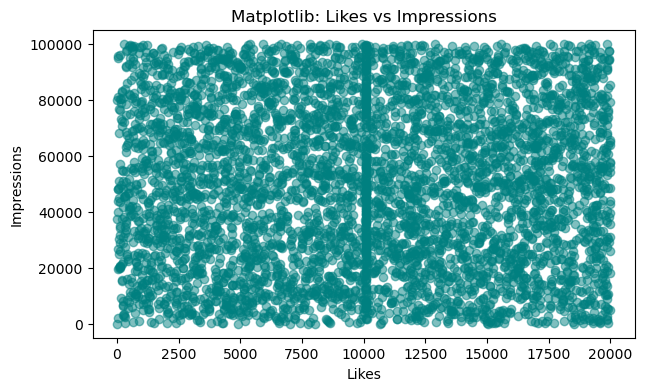

In [26]:
# 1. Matplotlib Scatter: Likes vs Impressions
plt.figure(figsize=(7, 4))
plt.scatter(df['likes'], df['impression_count'], alpha=0.5, color='teal')
plt.title('Matplotlib: Likes vs Impressions')
plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.show()

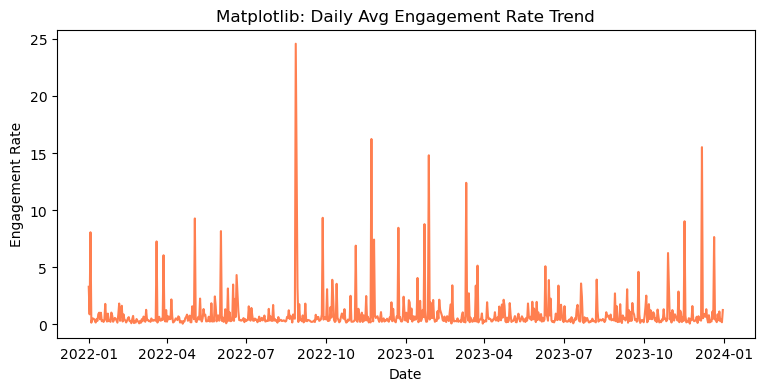

In [27]:
# 2. Matplotlib Line: Daily Engagement Trend
plt.figure(figsize=(9, 4))
daily_engagement = df.groupby('posted_at')['engagement_rate'].mean()
plt.plot(daily_engagement.index, daily_engagement.values, color='coral')
plt.title('Matplotlib: Daily Avg Engagement Rate Trend')
plt.xlabel('Date')
plt.ylabel('Engagement Rate')
plt.show()

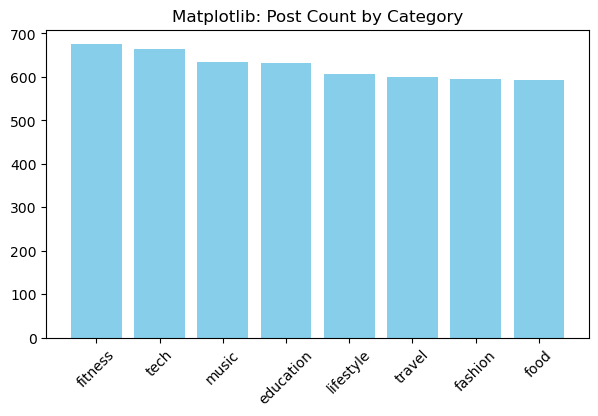

In [28]:
# 3. Matplotlib Bar: Posts by Category
plt.figure(figsize=(7, 4))
cat_counts = df['post_category'].value_counts()
plt.bar(cat_counts.index, cat_counts.values, color='skyblue')
plt.title('Matplotlib: Post Count by Category')
plt.xticks(rotation=45)
plt.show()

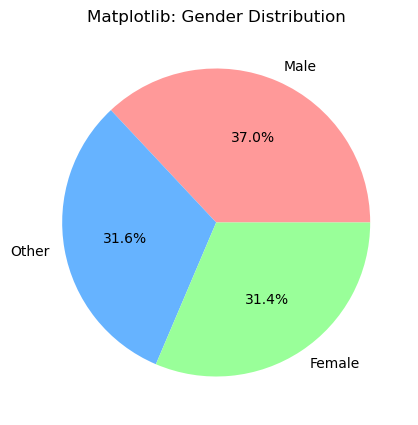

In [29]:
# 4. Matplotlib Pie: Gender Distribution
plt.figure(figsize=(5, 5))
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Matplotlib: Gender Distribution')
plt.show()

C:\Users\deepak k divakaran\AppData\Local\Temp\ipykernel_8948\326834103.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='post_type', palette='viridis')


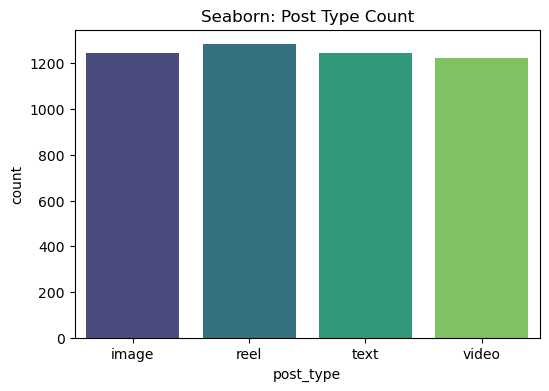

In [30]:
# 5. Seaborn Count Plot: Post Type
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='post_type', palette='viridis')
plt.title('Seaborn: Post Type Count')
plt.show()

C:\Users\deepak k divakaran\AppData\Local\Temp\ipykernel_8948\3596655588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sentiment', y='follower_count', palette='muted')


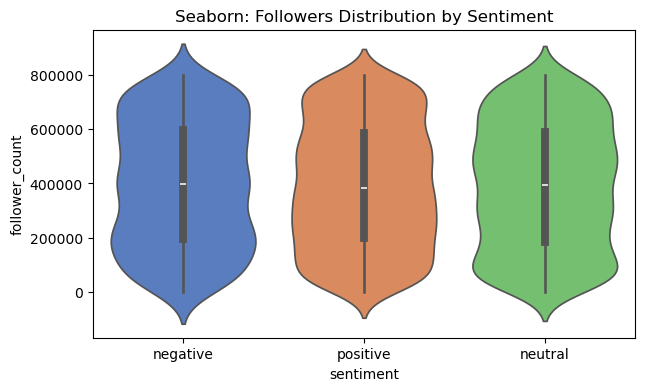

In [31]:
# 6. Seaborn Violin Plot: Followers vs Sentiment
plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x='sentiment', y='follower_count', palette='muted')
plt.title('Seaborn: Followers Distribution by Sentiment')
plt.show()

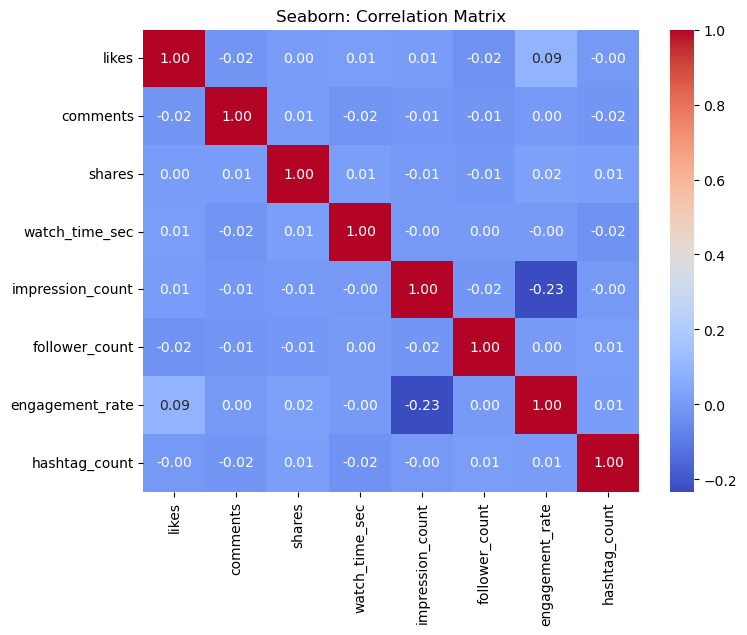

In [32]:
# 7. Seaborn Heatmap: Correlation Matrix
plt.figure(figsize=(8, 6))
numeric_cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'follower_count', 'engagement_rate', 'hashtag_count']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Seaborn: Correlation Matrix')
plt.show()

C:\Users\deepak k divakaran\AppData\Local\Temp\ipykernel_8948\2973381479.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='device_type', y='watch_time_sec', palette='Set2')


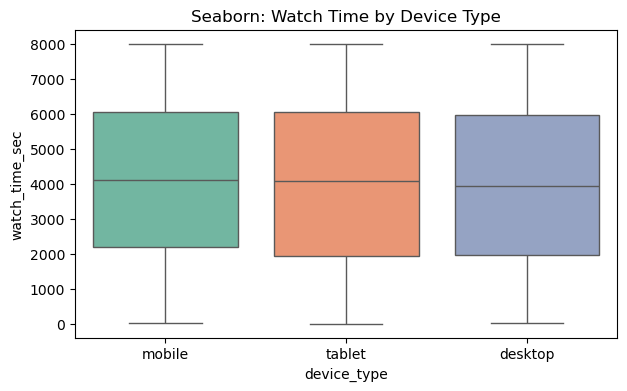

In [33]:
# 8. Seaborn Swarm/Boxplot: Engagement vs Device
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='device_type', y='watch_time_sec', palette='Set2')
plt.title('Seaborn: Watch Time by Device Type')
plt.show()

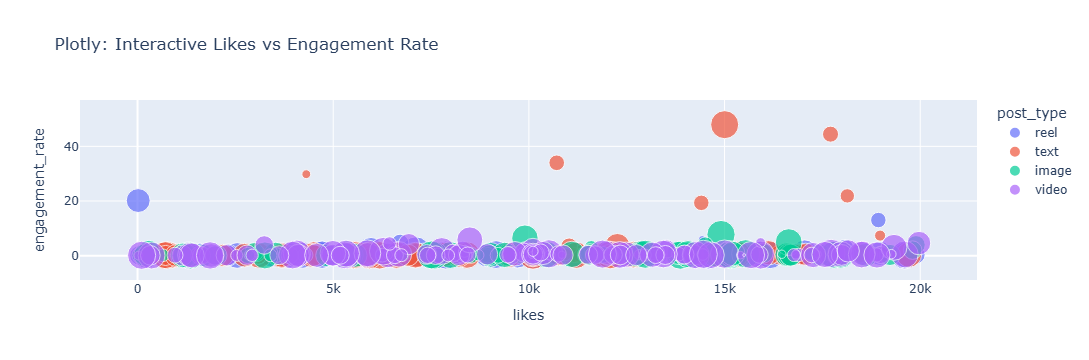

In [34]:
# 9. Plotly Interactive Chart
fig = px.scatter(df.sample(500), x="likes", y="engagement_rate", color="post_type", size="follower_count",
                 hover_data=['country', 'post_category'], title="Plotly: Interactive Likes vs Engagement Rate")
fig.show()

## Highest Performing Post Types: Videos (1.12 avg engagement rate) and Text posts (1.06) outperform Images (0.90) and Reels (0.78).

## Category Dynamics: Food posts generate the highest relative engagement rate (1.36), while Music leads in total raw engagement score ($16,395.44$ avg), driven by consistently higher likes ($10,205.75$).

## Geographic Variations: Brazil (1.54) and Australia (1.32) lead in average engagement rate, whereas the USA (0.58) and India (0.66) rank lowest in engagement efficiency despite generating higher raw impressions ($52,462.39$).

## Demographics: Engagement rates remain stable across age groups (18–25: 1.04, 51–65: 1.02), showing no severe drop-off among older demographics.

## Account Verification Impact: Verified accounts achieve a slightly higher engagement rate (1.05 vs. 0.95) and impression count ($50,747.34$ vs. $49,935.28$) despite having similar average follower levels in the dataset.

## Device Utilization: Mobile users achieve the longest average watch times ($4,087.83$ seconds) and highest engagement rates ($1.12$), significantly outperforming tablet users ($0.80$).

### Sentiment Dynamics: Negative sentiment posts register the highest engagement rate ($1.04$) and average likes ($10,208.10$), reflecting strong audience debate/reaction. Neutral sentiment posts show higher average comments ($1,528.40$).